# Taller Análisis Exploratorio de Datos
Juliana Casas Ramirez

## Paso 1: Carga de datos

Abra el archivo en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargar el archivo dado, que contiene un dataset cuya información puede consultar en [UCI](https://archive.ics.uci.edu/dataset/27/credit+approval).

De a las columnas los siguientes nombres:'A0',  'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15'.

Responda las siguientes preguntas:

- ¿Cuántas filas y columnas tiene el dataframe?
- ¿De qué tipo de dato es cada columna?
- ¿Las variables están en el tipo de dato correcto para su contenido?


In [72]:
import pandas as pd

columnas = ['A0', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7',
            'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15']

df = pd.read_csv(
    'crx.data',
    header=None,
    names=columnas,
    na_values='?'
)



df.head()

,A0,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


In [73]:
df.shape


(690, 16)

**1. ¿Cuántas filas y columnas tiene el dataframe?**

El dataframe tiene 690 filas y 16 columnas. Esto significa que la base de datos contiene información de 690 registros y cada registro tiene 16 características o variables.

**2. ¿De qué tipo de dato es cada columna?**

Los tipos de datos de las columnas son los siguientes:

In [99]:
# Permite observar la información general del dataframe, incluyendo el tipo de dato de cada columna y la cantidad de valores no nulos.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A0      678 non-null    object 
 1   A1      678 non-null    float64
 2   A2      690 non-null    float64
 3   A3      684 non-null    object 
 4   A4      684 non-null    object 
 5   A5      681 non-null    object 
 6   A6      681 non-null    object 
 7   A7      690 non-null    float64
 8   A8      690 non-null    object 
 9   A9      690 non-null    object 
 10  A10     690 non-null    int64  
 11  A11     690 non-null    object 
 12  A12     690 non-null    object 
 13  A13     677 non-null    float64
 14  A14     690 non-null    int64  
 15  A15     690 non-null    object 
dtypes: float64(4), int64(2), object(10)
memory usage: 86.4+ KB


Se observa que algunas variables están almacenadas como datos numéricos (int64 y float64), mientras que otras se encuentran como objetos (object) debido a que contienen valores categóricos representados por letras o símbolos. Estos tipos de datos permiten identificar la naturaleza de cada variable y facilitan el posterior análisis del conjunto de datos.


## Paso 2: Exploración inicial de los datos

Responda las siguientes preguntas:

- ¿Hay valores fuera de rango o imposibles, según el dominio del problema?
- ¿Hay variables que no varían?
- Qué variables *cualitativas* tienen muchos valores únicos (alta cardinalidad)?
- ¿Hay claves primarias o identificadores únicos?

**1. ¿Hay valores fuera de rango o imposibles, según el dominio del problema?**



In [75]:
# nos permite obtener un resumen estadístico de las variables numéricas del dataframe y tambien para revisar valores minios, maximos..
df.describe()

,A1,A2,A7,A10,A13,A14
count,678.000000,690.000000,690.000000,690.00000,677.000000,690.000000
mean,31.568171,4.758725,2.223406,2.40000,184.014771,1017.385507
std,11.957862,4.978163,3.346513,4.86294,173.806768,5210.102598
min,13.750000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,22.602500,1.000000,0.165000,0.00000,75.000000,0.000000
50%,28.460000,2.750000,1.000000,0.00000,160.000000,5.000000
75%,38.230000,7.207500,2.625000,3.00000,276.000000,395.500000
max,80.250000,28.000000,28.500000,67.00000,2000.000000,100000.000000


Al revisar el resumen estadístico de las variables cuantitativas, se analizaron los valores mínimos y máximos para identificar posibles datos fuera de rango. No se observaron valores que parecieran inconsistentes con la información del dataset.

**2. ¿Hay variables que no varían?**

In [76]:
# Este comando muestra la cantidad de valores diferentes que tiene cada columna.
# Si una columna tiene solamente un valor, significa que no presenta variación.

df.nunique()

,0
A0,2
A1,349
A2,215
A3,3
A4,3
A5,14
A6,9
A7,132
A8,2
A9,2


Al revisar la cantidad de valores únicos de cada variable, se observa que todas tienen más de un valor diferente. Por lo tanto, no se encontraron variables que tengan un único valor en todos sus registros.

**3. ¿Qué variables cualitativas tienen muchos valores únicos (alta cardinalidad)?**

In [77]:
# Este comando selecciona únicamente las columnas de tipo cualitativo (object) y muestra cuántos valores diferentes tiene cada una.
df.select_dtypes(include='object').nunique()

,0
A0,2
A3,3
A4,3
A5,14
A6,9
A8,2
A9,2
A11,2
A12,3
A15,2


Al revisar la cantidad de valores únicos de las variables cualitativas, se observa que A5 y A6 tienen la mayor cantidad de categorías con 14 y 9 valores respectivamente. Sin embargo, comparado con la cantidad total de registros, no presentan una cantidad excesiva de categorías.

**4. ¿Hay claves primarias o identificadores únicos?**

In [78]:
# Permite identificar si alguna columna tiene valores únicos para todos los registros

df.nunique()

,0
A0,2
A1,349
A2,215
A3,3
A4,3
A5,14
A6,9
A7,132
A8,2
A9,2


Al revisar la cantidad de valores únicos de cada variable, no se encontró ninguna columna con un valor diferente para cada registro. Por lo tanto, no se identifican variables que funcionen como clave primaria o identificador único.

## Paso 3: Identificación de datos duplicados, datos nulos y problemas de formateo

Descarte las variables que solo toman un valor y las que son clave primaria. También descarte las variables **City** y **Lat Long**.

Responda las siguientes preguntas:

- ¿Qué variables tienen valores nulos? ¿En qué proporción?
- ¿Hay registros duplicados?
- ¿Hay variables con problemas de formateo (fechas, monedas, mayúsculas/minúsculas)?

**1. ¿Qué variables tienen valores nulos? ¿En qué proporción?**

In [79]:
# Para identificar la cantidad de valores nulos que tiene cada variable del dataframe.
(df.isnull().sum()/df.shape[0])*100

,0
A0,1.739130
A1,1.739130
A2,0.000000
A3,0.869565
A4,0.869565
A5,1.304348
A6,1.304348
A7,0.000000
A8,0.000000
A9,0.000000


In [80]:
# Este cálculo permite obtener el porcentaje de valores nulos
(df.isnull().sum() / len(df)) * 100

,0
A0,1.739130
A1,1.739130
A2,0.000000
A3,0.869565
A4,0.869565
A5,1.304348
A6,1.304348
A7,0.000000
A8,0.000000
A9,0.000000


Al revisar los valores nulos del dataframe, se encontraron datos faltantes en las variables A0, A1, A3, A4, A5, A6 y A13. La variable con mayor porcentaje de valores faltantes es A13 con aproximadamente 1.88%. Estos valores corresponden a los datos que estaban representados con "?" en el archivo original y fueron reconocidos como valores nulos al cargar la base.

**2. ¿Hay registros duplicados?**

In [81]:
#identificar si existen filas repetidas

df.duplicated().sum()

np.int64(0)

Al revisar los registros duplicados mediante el comando df.duplicated().sum(), se obtuvo un resultado de 0, lo que indica que no existen filas repetidas dentro del conjunto de datos.

Por lo tanto, no es necesario eliminar registros duplicados, ya que cada fila del dataframe corresponde a un registro diferente.

**3. ¿Hay variables con problemas de formateo (fechas, monedas, mayúsculas/minúsculas)?**

In [82]:
#  revisar la información general del dataframe nos ayuda a ver si variable tiene un formato incorrecto

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A0      678 non-null    object 
 1   A1      678 non-null    float64
 2   A2      690 non-null    float64
 3   A3      684 non-null    object 
 4   A4      684 non-null    object 
 5   A5      681 non-null    object 
 6   A6      681 non-null    object 
 7   A7      690 non-null    float64
 8   A8      690 non-null    object 
 9   A9      690 non-null    object 
 10  A10     690 non-null    int64  
 11  A11     690 non-null    object 
 12  A12     690 non-null    object 
 13  A13     677 non-null    float64
 14  A14     690 non-null    int64  
 15  A15     690 non-null    object 
dtypes: float64(4), int64(2), object(10)
memory usage: 86.4+ KB


Al revisar la información general del dataframe, no se encontraron problemas de formato en las variables.

Las columnas numéricas tienen tipos de datos adecuados para representar valores cuantitativos, mientras que las variables categóricas se encuentran almacenadas como texto. Además, el dataset no contiene variables relacionadas con fechas o monedas que requieran algún cambio de formato.

Por lo tanto, no es necesario realizar modificaciones de formato en esta etapa del análisis.

## Paso 4: Análisis de variables cuantitativas

Haga análisis de normalidad de las variables cuantitativas. Indique cuáles variables cumplen con el supuesto de normalidad y cuáles no.

Haga un análisis gráfico de outliers, y como resultado de este indique que variables tienen datos atípicos.

**1. Haga análisis de normalidad de las variables cuantitativas. Indique cuáles variables cumplen con el supuesto de normalidad y cuáles no.**

In [96]:
# Selecciona las variables numéricas del dataframe estas variables serán utilizadas para analizar su distribución

num_vars = df.select_dtypes(include=["number"]).columns

num_vars

Index(['A1', 'A2', 'A7', 'A10', 'A13', 'A14'], dtype='object')

array([[<Axes: title={'center': 'A1'}>, <Axes: title={'center': 'A2'}>],
       [<Axes: title={'center': 'A7'}>, <Axes: title={'center': 'A10'}>],
       [<Axes: title={'center': 'A13'}>, <Axes: title={'center': 'A14'}>]],
      dtype=object)

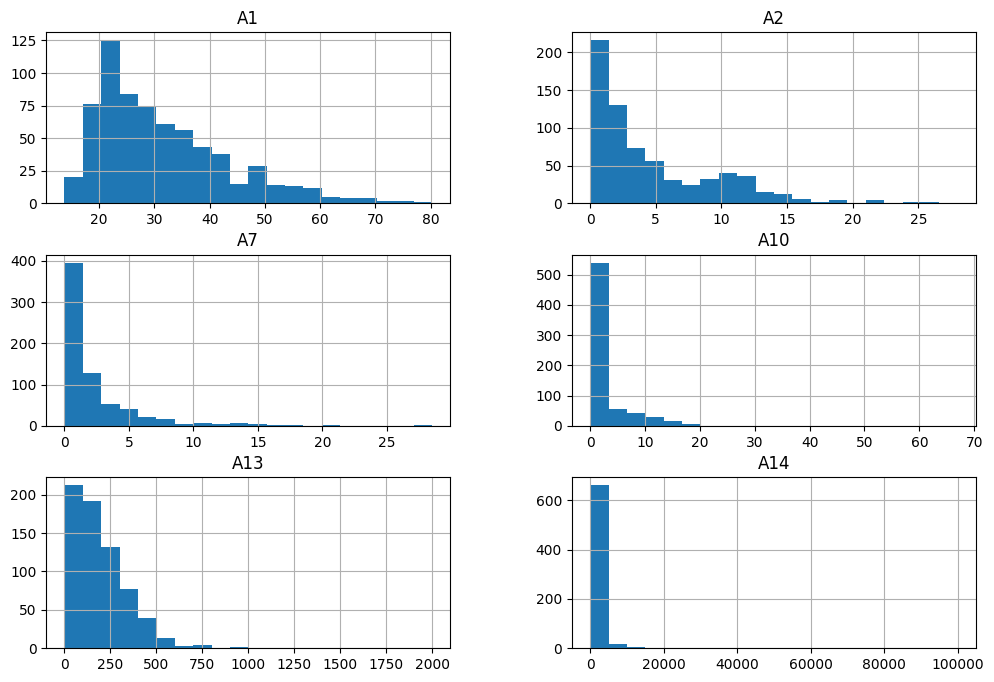

In [98]:
# Genera histogramas de las variables cuantitativas para observar la forma en que se distribuyen los datos

df[num_vars].hist(figsize=(12,8), bins=20)

Al observar los histogramas de las variables cuantitativas, se revisa si la forma de los datos se parece a una distribución normal.

Según la gráfica, las variables no presentan una forma completamente similar a una distribución normal, ya que algunas tienen los datos concentrados hacia ciertos valores y presentan inclinación en su distribución.

Por lo tanto, mediante el análisis gráfico realizado, no se observa un comportamiento claramente normal en las variables cuantitativas.

**2. Haga un análisis gráfico de outliers, y como resultado indique qué variables tienen datos atípicos.**

In [85]:
# Selecciona las variables cuantitativas del dataframe para realizar el análisis de valores atípicos
variables_cuantitativas = df.select_dtypes(include=['int64', 'float64'])

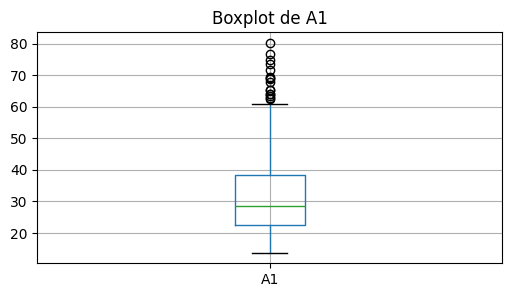

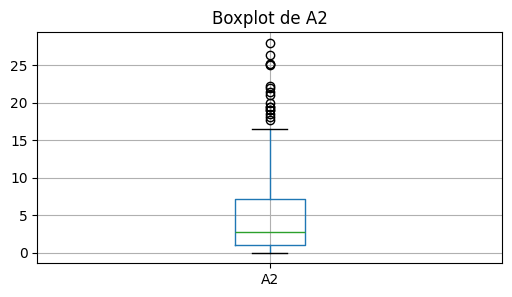

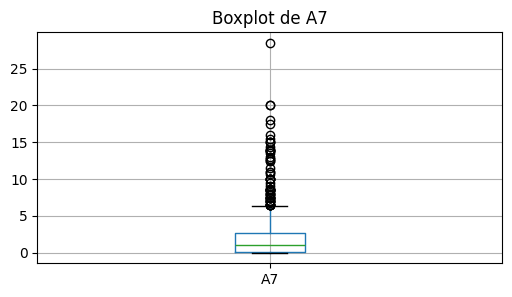

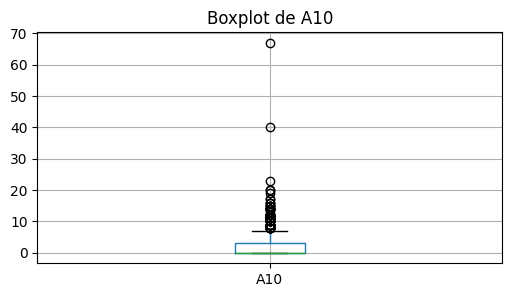

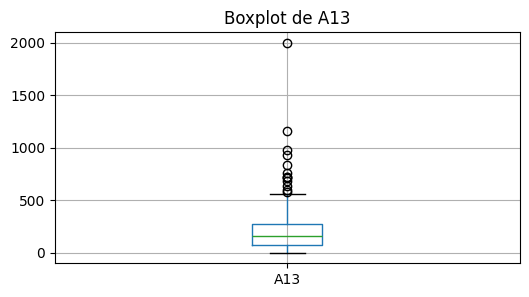

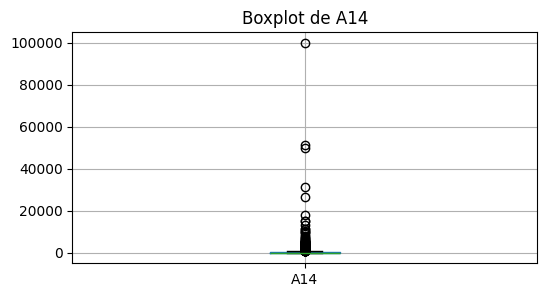

In [86]:
# Permite visualizar la distribución de las variables cuantitativas e identificar posibles valores atípicos
import matplotlib.pyplot as plt

for columna in variables_cuantitativas.columns:
    plt.figure(figsize=(6,3))
    df.boxplot(column=columna)
    plt.title(f'Boxplot de {columna}')
    plt.show()

Al realizar los diagramas de cajas de las variables cuantitativas, se observaron algunos valores alejados del comportamiento general de los datos.

Las variables que presentan posibles datos atípicos son principalmente A14, debido a la presencia de valores alejados del resto de registros, y también se observan algunos valores extremos en A13, A1, A2, A7 y A10.

Estos valores se identifican como posibles datos atípicos porque se encuentran fuera del rango donde se concentra la mayoría de los datos.

## Paso 5: Análisis de variables cualitativas

Responda a las siguientes preguntas:

- ¿Cómo se comportan las variables categóricas?
- ¿Existen variables de alta cardinalidad?
- ¿Existen categorías atípicas?

**1. ¿Cómo se comportan las variables categóricas?**

In [87]:
# Selecciona las variables cualitativas del dataframe estas variables contienen categorías o valores de texto.

variables_cualitativas = df.select_dtypes(include=['object'])

variables_cualitativas.head()

,A0,A3,A4,A5,A6,A8,A9,A11,A12,A15
0,b,u,g,w,v,t,t,f,g,+
1,a,u,g,q,h,t,t,f,g,+
2,a,u,g,q,h,t,f,f,g,+
3,b,u,g,w,v,t,t,t,g,+
4,b,u,g,w,v,t,f,f,s,+


In [100]:
# Permite conocer los valores que tiene cada variable cualitativa
# y la cantidad de veces que aparece cada categoría.

for columna in variables_cualitativas.columns:
    print("Variable:", columna)
    print(df[columna].value_counts())
    print("----------------")

Variable: A0
A0
b    468
a    210
Name: count, dtype: int64
----------------
Variable: A3
A3
u    519
y    163
l      2
Name: count, dtype: int64
----------------
Variable: A4
A4
g     519
p     163
gg      2
Name: count, dtype: int64
----------------
Variable: A5
A5
c     137
q      78
w      64
i      59
aa     54
ff     53
k      51
cc     41
x      38
m      38
d      30
e      25
j      10
r       3
Name: count, dtype: int64
----------------
Variable: A6
A6
v     399
h     138
bb     59
ff     57
j       8
z       8
dd      6
n       4
o       2
Name: count, dtype: int64
----------------
Variable: A8
A8
t    361
f    329
Name: count, dtype: int64
----------------
Variable: A9
A9
f    395
t    295
Name: count, dtype: int64
----------------
Variable: A11
A11
f    374
t    316
Name: count, dtype: int64
----------------
Variable: A12
A12
g    625
s     57
p      8
Name: count, dtype: int64
----------------


Las variables categóricas presentan diferentes comportamientos dependiendo de sus categorías. En algunas variables existe una categoría que concentra la mayoría de los registros, mientras que otras categorías tienen una menor cantidad de apariciones. En general, las variables cualitativas tienen pocas categorías y no presentan una cantidad excesiva de valores diferentes.

**2. ¿Existen variables de alta cardinalidad?**

In [89]:
# Este comando muestra la cantidad de valores únicos que tiene cada variable cualitativa

variables_cualitativas.nunique()

,0
A0,2
A3,3
A4,3
A5,14
A6,9
A8,2
A9,2
A11,2
A12,3
A15,2


Al revisar la cantidad de valores únicos de las variables cualitativas, se observa que las variables con mayor número de categorías son A5 con 14 valores y A6 con 9 valores.

Sin embargo, comparando esta cantidad con el número total de registros del dataset, no se consideran variables con alta cardinalidad, ya que no tienen una cantidad muy elevada de categorías diferentes.

**3. ¿Existen categorías atípicas?**

In [90]:
# Permite observar la frecuencia de cada categoría dentro de las variables cualitativas, sirve para identificar categorías con pocas apariciones

for columna in variables_cualitativas.columns:
    print("Variable:", columna)
    print(df[columna].value_counts())
    print("----------------")

Variable: A0
A0
b    468
a    210
Name: count, dtype: int64
----------------
Variable: A3
A3
u    519
y    163
l      2
Name: count, dtype: int64
----------------
Variable: A4
A4
g     519
p     163
gg      2
Name: count, dtype: int64
----------------
Variable: A5
A5
c     137
q      78
w      64
i      59
aa     54
ff     53
k      51
cc     41
x      38
m      38
d      30
e      25
j      10
r       3
Name: count, dtype: int64
----------------
Variable: A6
A6
v     399
h     138
bb     59
ff     57
j       8
z       8
dd      6
n       4
o       2
Name: count, dtype: int64
----------------
Variable: A8
A8
t    361
f    329
Name: count, dtype: int64
----------------
Variable: A9
A9
f    395
t    295
Name: count, dtype: int64
----------------
Variable: A11
A11
f    374
t    316
Name: count, dtype: int64
----------------
Variable: A12
A12
g    625
s     57
p      8
Name: count, dtype: int64
----------------
Variable: A15
A15
-    383
+    307
Name: count, dtype: int64
----------------


Al analizar la frecuencia de las categorías, se identificaron algunos valores con pocas apariciones en variables como A3, A4, A5, A6 y A12.

Estas categorías tienen una menor representación dentro del dataset, pero no se modifican en esta etapa porque hacen parte de los datos originales y primero deben ser analizadas antes de realizar algún cambio.

## Paso 6: Análisis bivariado

Se va a suponer que con este archivo de datos se desea hacer un modelo de aprendizaje de máquina que prediga la vaariable **A15**.


Mediante análisis de gráficas responda las siguientes preguntas:

- ¿Cómo se relaciona cada una de las variables cuantitativas con la variable que se desea predecir?
- ¿Cómo se relaciona cada una de las variables cualitativas con la variable que se desea predecir?
- De acuerdo con estos análisis, ¿cuáles variables parecerían ser buenas predictoras, y cuáles no?


**1. ¿Cómo se relaciona cada una de las variables cuantitativas con la variable que se desea predecir?**

In [91]:
# Selecciona las variables cuantitativas del datafram estas variables serán comparadas con la variable objetivo A15.

variables_cuantitativas = df.select_dtypes(include=['int64','float64'])

variables_cuantitativas.head()

,A1,A2,A7,A10,A13,A14
0,30.83,0.000,1.25,1,202.0,0
1,58.67,4.460,3.04,6,43.0,560
2,24.50,0.500,1.50,0,280.0,824
3,27.83,1.540,3.75,5,100.0,3
4,20.17,5.625,1.71,0,120.0,0


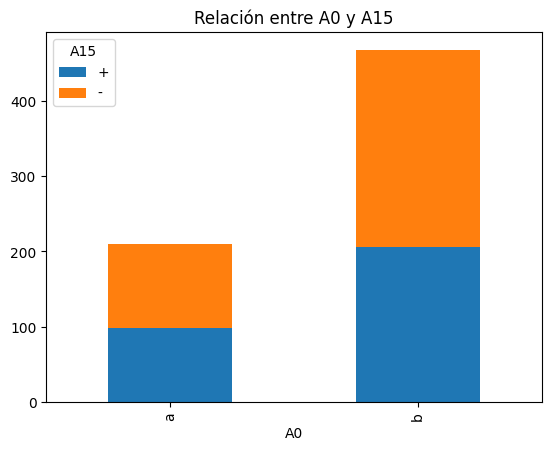

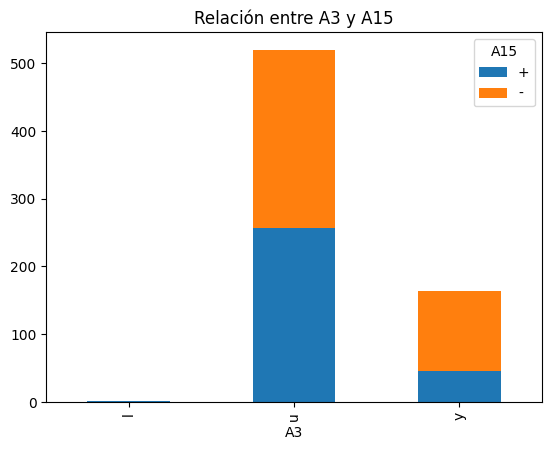

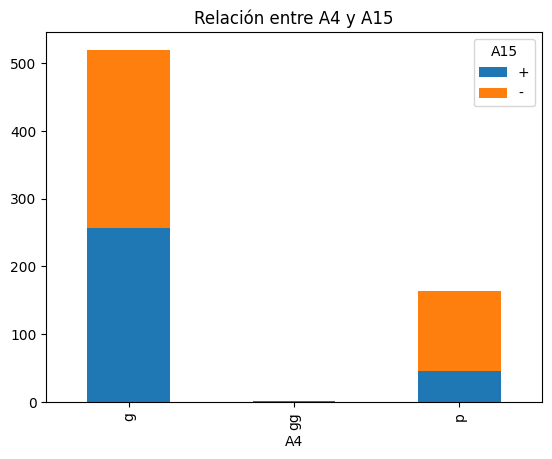

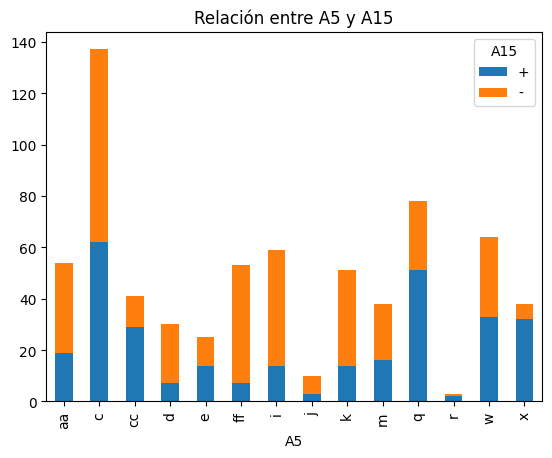

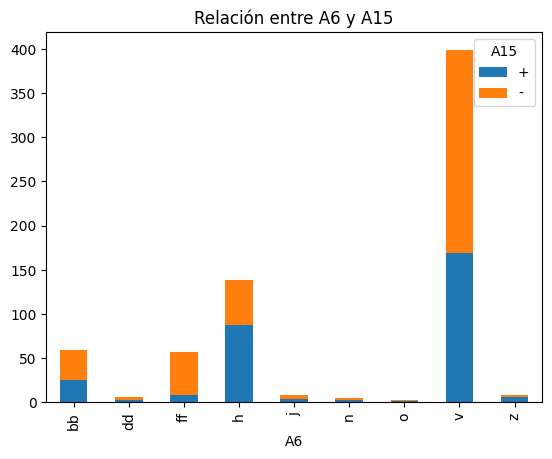

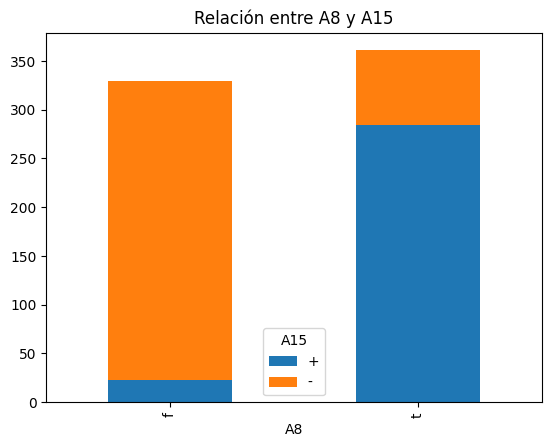

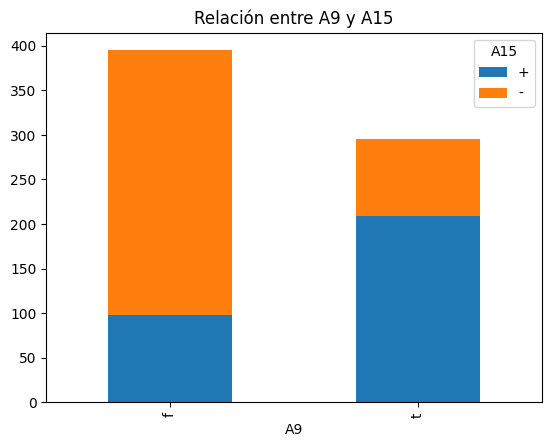

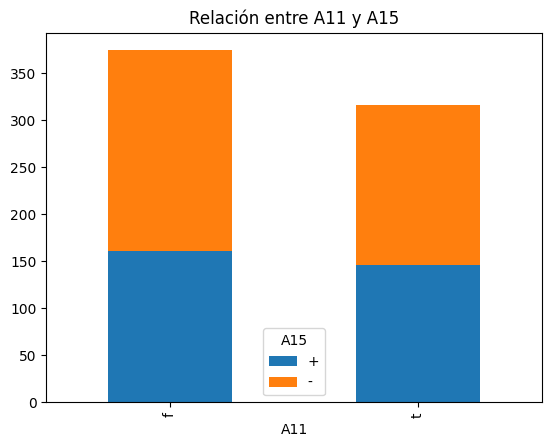

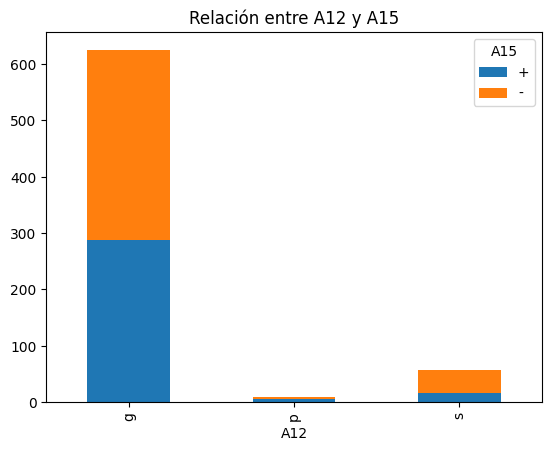

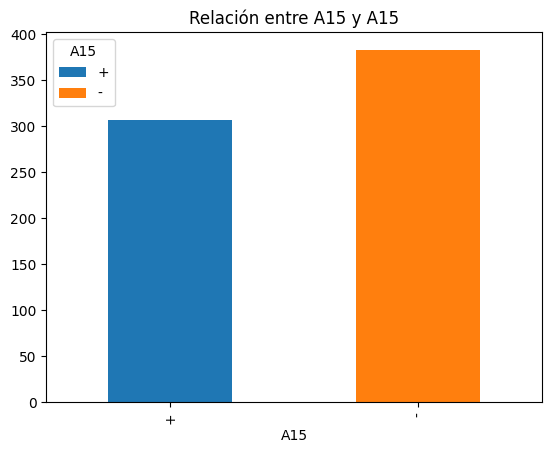

In [92]:
import matplotlib.pyplot as plt

# Permite observar la distribución de cada variable cuantitativa separada por la categoría de A15

for columna in variables_cualitativas.columns:
    tabla = pd.crosstab(df[columna], df['A15'])
    tabla.plot(kind='bar', stacked=True)
    plt.title(f'Relación entre {columna} y A15')
    plt.show()

Al comparar las variables cuantitativas con la variable objetivo A15, se observan diferencias en la distribución de algunas variables entre las dos categorías de A15.

Las variables A2 y A7 muestran diferencias más claras entre los grupos, por lo que podrían tener mayor relación con la variable que se desea predecir.

Las variables A1, A10 y A14 también presentan diferencias, aunque con mayor variación entre los datos. Por otro lado, A13 presenta un comportamiento más similar entre los grupos.

**2. ¿Cómo se relaciona cada una de las variables cualitativas con la variable que se desea predecir?**

In [93]:
# Selecciona las variables cualitativas del dataframe se excluye A15 porque es la variable que se desea predecir

variables_cualitativas = df.select_dtypes(include=['object']).drop(columns=['A15'])

In [94]:
# Permite observar cómo se distribuyen las categorías de cada variable cualitativa según la variable objetivo A15

for columna in variables_cualitativas.columns:
    print("Variable:", columna)
    print(pd.crosstab(df[columna], df['A15']))
    print("----------------")

Variable: A0
A15    +    -
A0           
a     98  112
b    206  262
----------------
Variable: A3
A15    +    -
A3           
l      2    0
u    256  263
y     45  118
----------------
Variable: A4
A15    +    -
A4           
g    256  263
gg     2    0
p     45  118
----------------
Variable: A5
A15   +   -
A5         
aa   19  35
c    62  75
cc   29  12
d     7  23
e    14  11
ff    7  46
i    14  45
j     3   7
k    14  37
m    16  22
q    51  27
r     2   1
w    33  31
x    32   6
----------------
Variable: A6
A15    +    -
A6           
bb    25   34
dd     2    4
ff     8   49
h     87   51
j      3    5
n      2    2
o      1    1
v    169  230
z      6    2
----------------
Variable: A8
A15    +    -
A8           
f     23  306
t    284   77
----------------
Variable: A9
A15    +    -
A9           
f     98  297
t    209   86
----------------
Variable: A11
A15    +    -
A11          
f    161  213
t    146  170
----------------
Variable: A12
A15    +    -
A12          
g    28

Al analizar las variables cualitativas frente a A15, se observa que algunas categorías presentan diferencias en la cantidad de registros asociados a cada resultado de A15.

Las variables A5, A6, A8 y A9 muestran cambios más notorios entre sus categorías, por lo que parecen tener mayor relación con la variable objetivo.

Otras variables presentan distribuciones más similares entre sus categorías, por lo que aparentemente tienen menor relación con A15.

**3. De acuerdo con estos análisis, ¿cuáles variables parecerían ser buenas predictoras y cuáles no?**

Según los análisis realizados, las variables que muestran mayores diferencias frente a A15 son A2, A7, A5, A6, A8 y A9, por lo que podrían tener mayor importancia en un modelo de predicción. Sin embargo, esto debe comprobarse posteriormente al entrenar y evaluar el modelo.